# PricePoint — 08 · Compare the models

**Run notebooks 02–07 first** — each one saves its scores to `models/metrics_*.json`. (Run `09_tune_gradient_boosting.ipynb` and then re-run this notebook to see the tuned model in the table too.)

This notebook reads those files, adds a **baseline** (a "model" that always predicts the average price — the score every real model must beat), puts everything in one table, draws a chart, and picks the winner: **the real model with the lowest cross-validated MAE** (average error in taka).

In [1]:
import json

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:

if Path.cwd().name == "notebooks":
    DATA_DIR = Path("../data")
    MODEL_DIR = Path("../models")
else:
    DATA_DIR = Path("data")
    MODEL_DIR = Path("models")

In [3]:

metric_files = sorted(MODEL_DIR.glob("metrics_*.json"))

rows = []
for file in metric_files:
    with open(file) as f:
        rows.append(json.load(f))

results = pd.DataFrame(rows)

if results.empty:
    print("No metrics found.")
    print("Run notebooks 02 to 07 first — each one saves a metrics file here.")
else:
    
    results = results.sort_values("cv_mae").reset_index(drop=True)

## The baseline: the score to beat

The baseline ignores every spec and **always predicts the average price**. If a model cannot do clearly better than this, it has learned nothing useful.

In [4]:

from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

if not results.empty:
    clean = pd.read_csv(DATA_DIR / "laptop_price_clean.csv")
    X = clean[["ram_gb"]]          
    y = clean["price_bdt"]

    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    baseline = DummyRegressor(strategy="mean")
    baseline.fit(X_train, y_train)
    y_pred = baseline.predict(X_test)

    cv_mae = -cross_val_score(baseline, X, y, cv=5, scoring="neg_mean_absolute_error")
    cv_rmse = -cross_val_score(baseline, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_r2 = cross_val_score(baseline, X, y, cv=5, scoring="r2")

    baseline_row = {
        "model": "Baseline (average price)",
        "test_mae": round(mean_absolute_error(y_test, y_pred), 2),
        "test_rmse": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        "test_r2": round(r2_score(y_test, y_pred), 4),
        "cv_mae": round(cv_mae.mean(), 2),
        "cv_rmse": round(cv_rmse.mean(), 2),
        "cv_r2": round(cv_r2.mean(), 4),
    }

    results = pd.concat([results, pd.DataFrame([baseline_row])])
    results = results.sort_values("cv_mae").reset_index(drop=True)

## The table — sorted by CV MAE, lower is better

In [5]:
results

,model,test_mae,test_rmse,test_r2,cv_mae,cv_rmse,cv_r2
0,Random Forest,23021.73,39402.86,0.8259,22695.25,36517.82,0.8234
1,Gradient Boosting (tuned),21994.61,38798.05,0.8103,24595.07,38979.01,0.7963
2,Gradient Boosting,21398.15,37563.70,0.8222,24600.95,36880.53,0.8169
3,Decision Tree,30412.44,55942.95,0.6490,29513.42,48678.79,0.6799
4,KNN,30032.43,47128.98,0.7201,30994.55,46769.06,0.7067
5,Linear Regression,41015.62,55951.60,0.6489,40040.02,54078.77,0.6135
6,SVR,63216.28,95580.00,-0.0247,65205.22,89305.69,-0.0481
7,Baseline (average price),64329.55,89133.61,-0.0011,67229.99,87511.93,-0.0218


## The chart

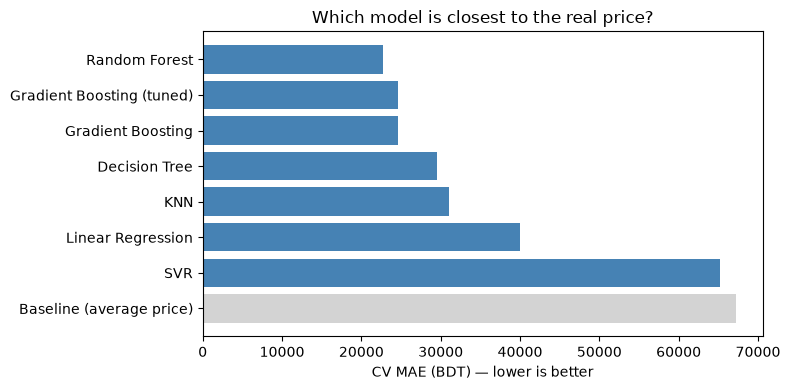

In [6]:
if not results.empty:
    colors = ["lightgray" if m.startswith("Baseline") else "steelblue" for m in results["model"]]

    plt.figure(figsize=(8, 4))
    plt.barh(results["model"], results["cv_mae"], color=colors)
    plt.xlabel("CV MAE (BDT) — lower is better")
    plt.title("Which model is closest to the real price?")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## The winner

In [7]:
if not results.empty:

    is_baseline = results["model"].str.startswith("Baseline")
    best = results[~is_baseline].iloc[0]                 
    baseline_mae = results[is_baseline]["cv_mae"].iloc[0]

    print("Best model:", best["model"])
    print("CV MAE :", best["cv_mae"], "BDT")
    print("CV RMSE:", best["cv_rmse"], "BDT")
    print("CV R²  :", best["cv_r2"])
    print()
    print(f"Just guessing the average price is off by {baseline_mae:,.0f} BDT on average,")
    print(f"so the best model's error is {1 - best['cv_mae'] / baseline_mae:.0%} smaller.")
    print()
    print("Next notebook: 09_tune_gradient_boosting.ipynb")

Best model: Random Forest
CV MAE : 22695.25 BDT
CV RMSE: 36517.82 BDT
CV R²  : 0.8234

Just guessing the average price is off by 67,230 BDT on average,
so the best model's error is 66% smaller.

Next notebook: 09_tune_gradient_boosting.ipynb
